In [100]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

In [41]:
df = pd.read_csv("/content/creditcard.csv")

In [42]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [43]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


So, there have some missing values. I will work on it now.

In [44]:
df.shape


(284807, 31)

In [45]:
df = df.dropna()

In [46]:
df.shape

(284807, 31)

In [47]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


So the missing vlues are removed.

In [48]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


In [49]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

so I have only 0.24% fraud data and others all are normal data!

Now we will apply standarscaler in amount columns..

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Amount'].head()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


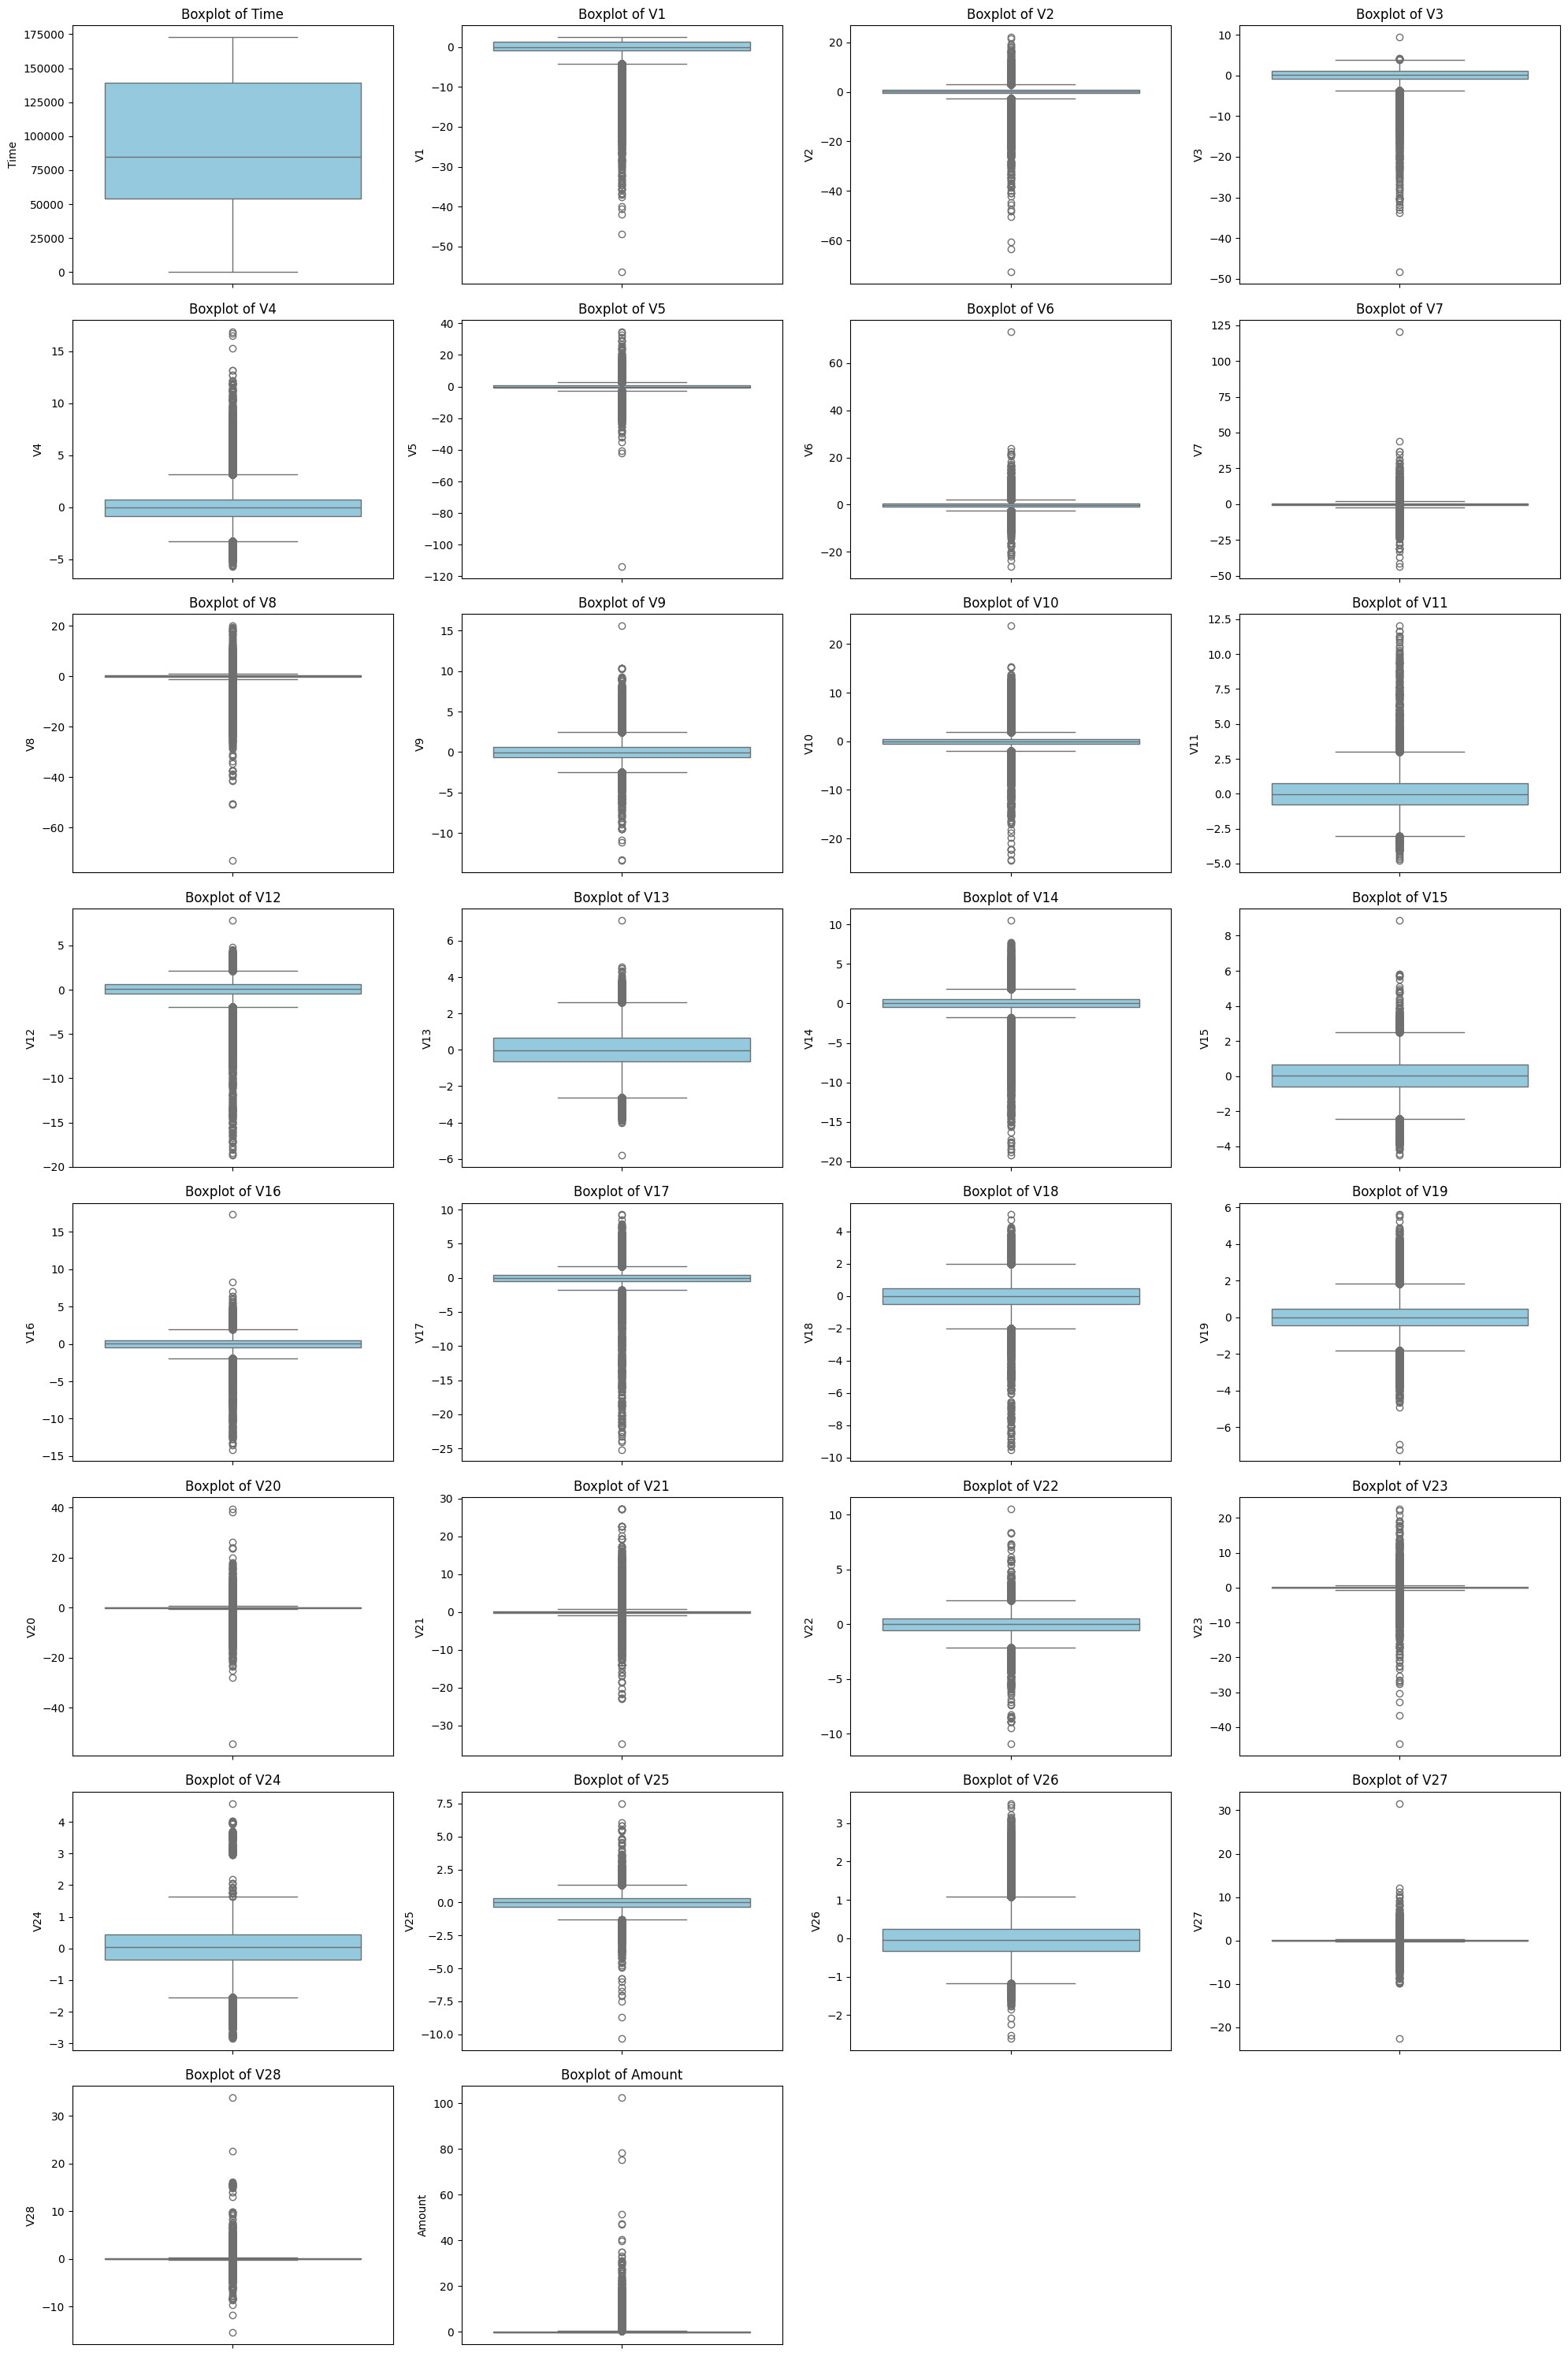

In [51]:

cols = df.drop(columns=['Class']).columns


plt.figure(figsize=(20, 30))

for i, col in enumerate(cols):
    plt.subplot(8, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()


There is a lot of outliars but it's normal for the fraud detection data set. I'll go with that

In [56]:
df['Class'] = df['Class'].astype(int)

In [69]:
x = df.drop(columns=['Class'])
y = df['Class']

x_train,x_test, y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)
y_train

,Class
223361,0
165061,0
238186,0
150562,0
138452,0
...,...
119879,0
259178,0
131932,0
146867,0


In [70]:

df['Class'] = df['Class'].astype(int)

In [76]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print(sum(y_train_res == 0))
print(sum(y_train_res == 1))

227451
227451


SMOTE is perfectly applied.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


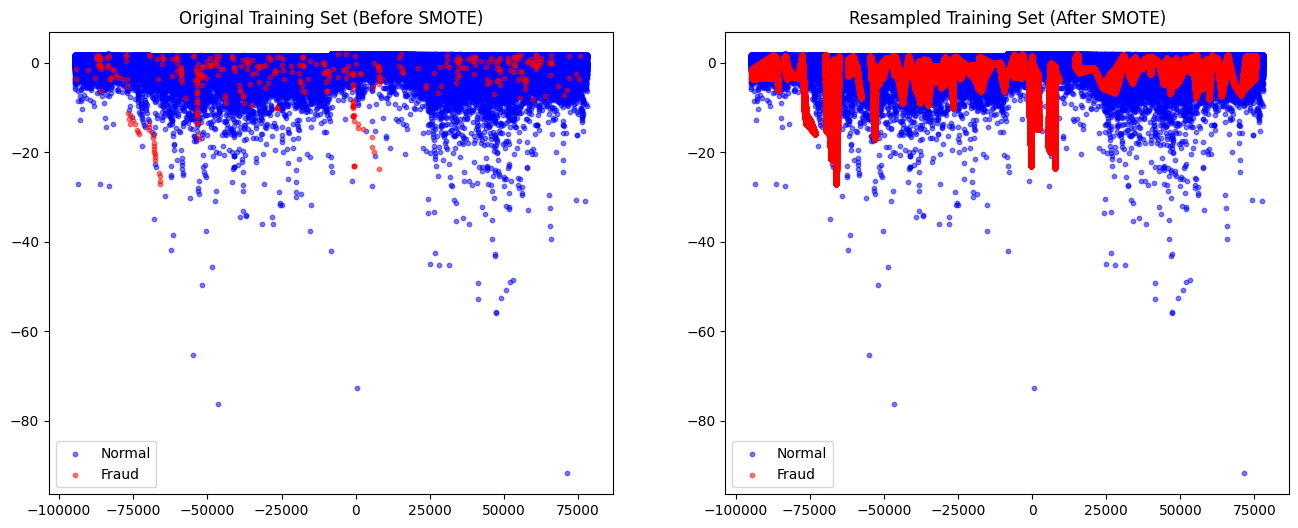

In [101]:

from sklearn.decomposition import PCA



pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(x_train)



X_train_res_pca = pca.transform(x_train_res)


plt.figure(figsize=(16, 6))


plt.subplot(1, 2, 1)
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], label="Normal", alpha=0.5, color='blue', s=10)
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], label="Fraud", alpha=0.5, color='red', s=10)
plt.title("Original Training Set (Before SMOTE)")
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(X_train_res_pca[y_train_res == 0, 0], X_train_res_pca[y_train_res == 0, 1], label="Normal", alpha=0.5, color='blue', s=10)
plt.scatter(X_train_res_pca[y_train_res == 1, 0], X_train_res_pca[y_train_res == 1, 1], label="Fraud", alpha=0.5, color='red', s=10)
plt.title("Resampled Training Set (After SMOTE)")
plt.legend()

plt.show()


In [81]:
from sklearn.ensemble import RandomForestClassifier
final_model = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)

final_model.fit(x_train_res, y_train_res)

print("Model Training Successful!")

Model Training Successful!


In [86]:
y_pred = final_model.predict(x_test)


from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Overall Accuracy: {accuracy * 100:.2f}%")

Model Overall Accuracy: 99.88%


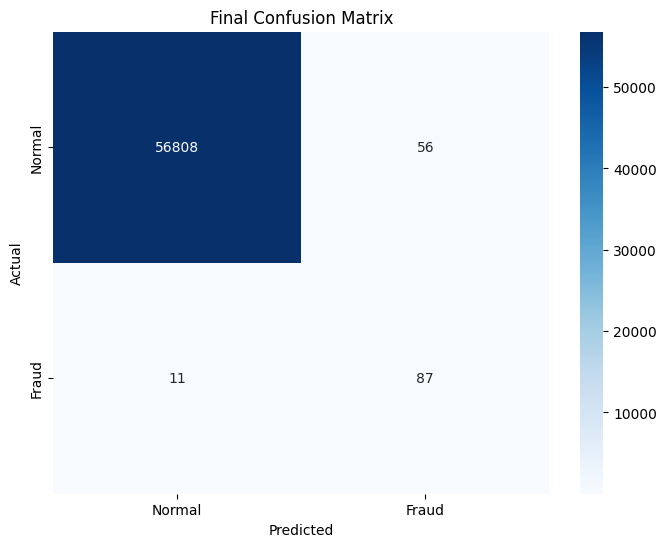

In [87]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix')
plt.show()

In [95]:
final_model = RandomForestClassifier(n_estimators=20, class_weight={0: 1, 1: 5},
                                     random_state=42,
                                     n_jobs=-1)

final_model.fit(x_train_res, y_train_res)


RandomForestClassifier(class_weight={0: 1, 1: 5}, n_estimators=20, n_jobs=-1,
                       random_state=42)

Here I have wanted to make my model more specific with class_weight.

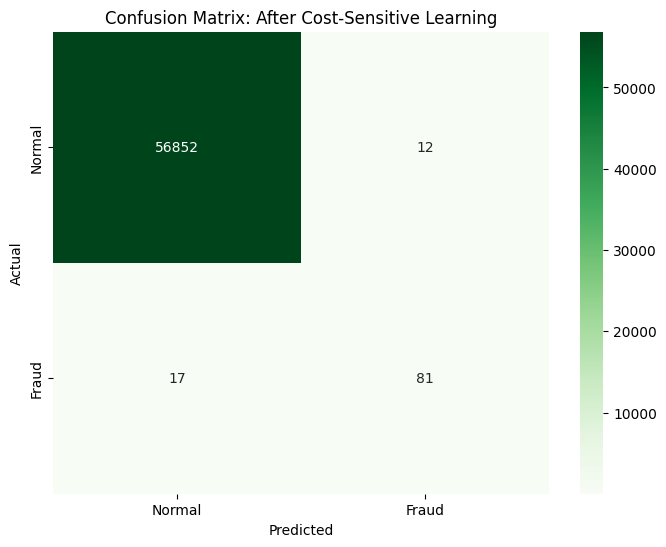

In [96]:
y_pred_cost = final_model.predict(x_test)


cm_cost = confusion_matrix(y_test, y_pred_cost)


plt.figure(figsize=(8,6))
sns.heatmap(cm_cost, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: After Cost-Sensitive Learning')
plt.show()

ROC-AUC Score: 0.9434


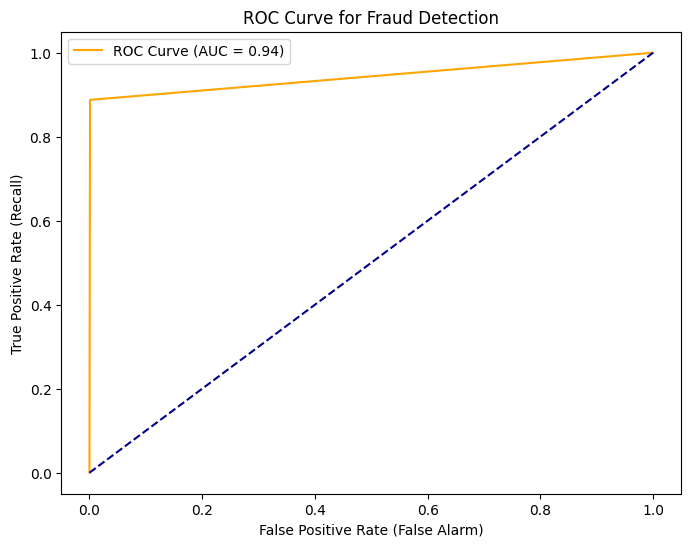

In [99]:
from sklearn.metrics import roc_auc_score, roc_curve

auc_score = roc_auc_score(y_test, y_pred)
print(f"ROC-AUC Score: {auc_score:.4f}")


fpr, tpr, thresholds = roc_curve(y_test, y_pred)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate (False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Fraud Detection')
plt.legend()
plt.show()